In [44]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/1.01. Simple linear regression.csv') #Importing dataset
df

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
79,1936,3.71
80,1810,3.71
81,1987,3.73
82,1962,3.76


In [3]:
print(df.shape)

(84, 2)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     84 non-null     int64  
 1   GPA     84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [6]:
df.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


In [19]:
#Declare feature and target variable
x = df['SAT'].values
y = df['GPA'].values

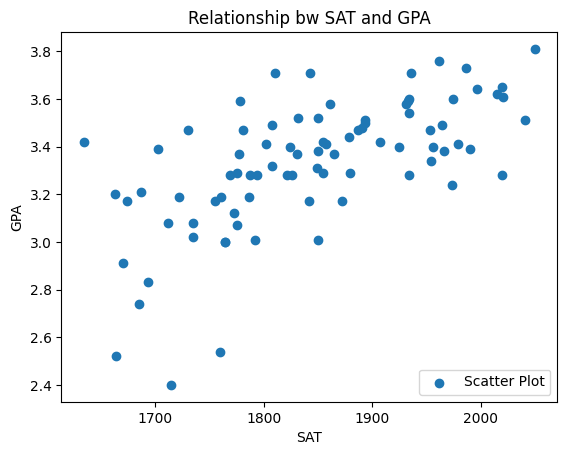

In [102]:
#Visual EDA
plt.scatter(x,y, label='Scatter Plot')
plt.title("Relationship bw SAT and GPA")
plt.xlabel('SAT')
plt.ylabel('GPA')
plt.legend(loc=4)
plt.show()


In [103]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)
#Reshaping x and y
print(x.shape)
print(y.shape) #New dimensions

(84, 1)
(84, 1)


In [104]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)


In [105]:
#Dimensions of x_train, x_test, y_train, y_test
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(58, 1)
(58, 1)
(13, 1)
(13, 1)


In [106]:
#Fit the linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression() #Instantiate the linear regression object

lm.fit(x_train, y_train) #Train the model using training datasets

y_pred = lm.predict(x_test) #Make predictions using testing set


In [107]:
a = lm.coef_
b = lm.intercept_
print("Estimated model slope: ",a)
print("Estimated model intercept: ",b)
#

Estimated model slope:  [[0.00157377]]
Estimated model intercept:  [0.4435746]


In [108]:
lm.predict(x)

array([[3.14102329],
       [3.06233459],
       [3.2134169 ],
       [3.09538384],
       [3.10797404],
       [3.07177723],
       [3.21971199],
       [3.21971199],
       [3.26377766],
       [3.35505656],
       [3.17407255],
       [3.23702351],
       [3.17407255],
       [3.13787574],
       [3.23387596],
       [3.38967959],
       [3.20554803],
       [3.07807233],
       [3.34246637],
       [3.25433502],
       [3.21499067],
       [3.15361348],
       [3.06076082],
       [3.09853139],
       [3.55020454],
       [3.31728598],
       [3.25590879],
       [3.30941711],
       [3.62259814],
       [3.26692521],
       [3.22758086],
       [3.48725358],
       [3.23702351],
       [3.36292543],
       [3.40226978],
       [3.35348278],
       [3.28895805],
       [3.51872906],
       [3.24017105],
       [3.32515485],
       [3.37866317],
       [3.35505656],
       [3.53761435],
       [3.122138  ],
       [3.57538492],
       [3.47308961],
       [3.31413843],
       [3.521

In [109]:
#Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE value: {:.4f}".format(rmse))

RMSE value: 0.2805


In [110]:
#Calculate R2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 score value: {:.4f}".format(r2))

R2 score value: 0.3533


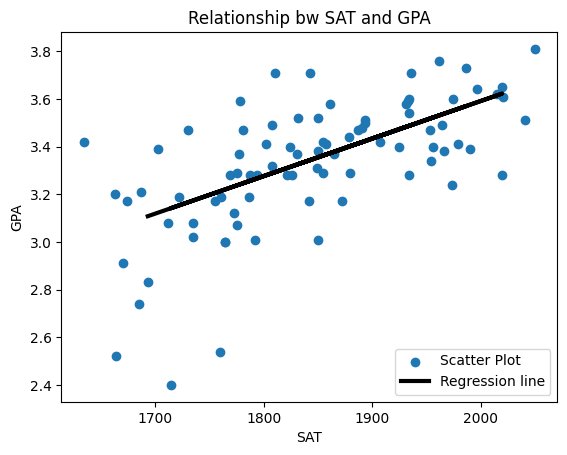

In [111]:
#Plot the regeression line
plt.scatter(x,y, label='Scatter Plot')
plt.plot(x_test, y_pred, color='black', linewidth=3, label = 'Regression line')
plt.title("Relationship bw SAT and GPA")
plt.xlabel('SAT')
plt.ylabel('GPA')
plt.legend(loc=4)
plt.show()

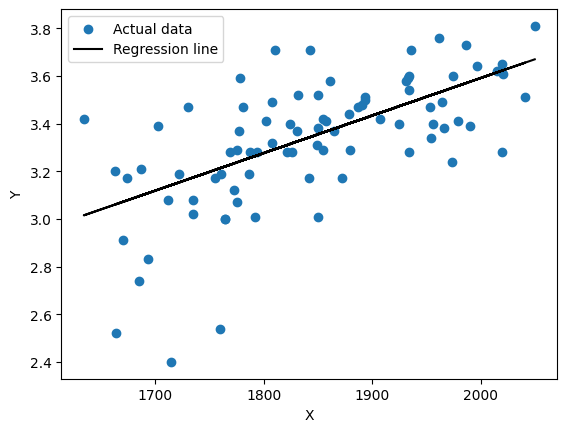

In [112]:
plt.scatter(x, y, label="Actual data")
plt.plot(x, lm.predict(x), color='black', label="Regression line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


In [113]:
print("Training set score: {:.4f}".format(lm.score(x_train, y_train)))
print("Validation set score: {:.4f}".format(lm.score(x_val, y_val)))
print("Test set score: {:.4f}".format(lm.score(x_test, y_test)))

Training set score: 0.3999
Validation set score: 0.5393
Test set score: 0.3533


In [101]:
sat_score = int(input("Enter SAT score: "))
prediction = lm.predict([[sat_score]])

print("Predicted GPA:", prediction)


Enter SAT score: 3333
Predicted GPA: [[5.68896344]]
